In [17]:
import pandas as pd
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [ ]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# INITIAL OBSERVATIONS
Dataset: e-commerce order placement


Rows: 1200


Columns: 14


Numerical Columns: Quantity, Unit price (decimal), itemsInCart, TotalPrice (decimal)


Text columns: OrderID, CustomerID, Shipping Address, TracingNumber


Categorical columns: Product, PaymentMethod, OrderStatus, CouponCode, ReferralSource


Date: Date


Possible Issues:

missing rows in CouponCode



# MISSING VALUES


In [19]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [20]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [21]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [22]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

OrderID            0.0
Date               0.0
CustomerID         0.0
Product            0.0
Quantity           0.0
UnitPrice          0.0
ShippingAddress    0.0
PaymentMethod      0.0
OrderStatus        0.0
TrackingNumber     0.0
ItemsInCart        0.0
CouponCode         0.0
ReferralSource     0.0
TotalPrice         0.0
dtype: float64


# OUTLIERS


In [23]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='object')

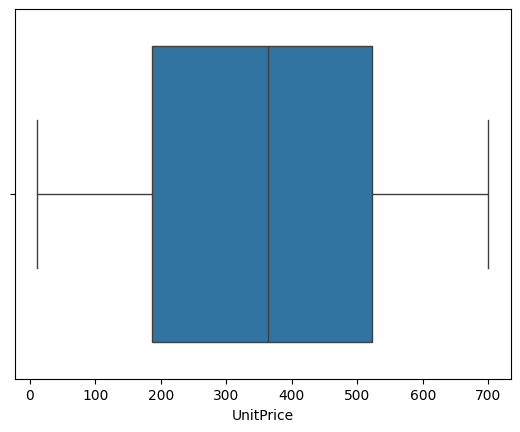

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df["UnitPrice"])
plt.show()

In [25]:
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", IQR)
print("lower bound: ", lower_bound)
print("upper bound: ", upper_bound)


outliers = df[
    (df["UnitPrice"] < lower_bound) |
    (df["UnitPrice"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Q1:  186.0625
Q3:  521.5699999999999
IQR:  335.50749999999994
lower bound:  -317.1987499999999
upper bound:  1024.8312499999997
Number of outliers: 0


In [26]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", IQR)
print("lower bound: ", lower_bound)
print("upper bound: ", upper_bound)

outliers = df[
    (df["Quantity"] < lower_bound) |
    (df["Quantity"] > upper_bound)
]

print("Number of outliers:", len(outliers))


Q1:  2.0
Q3:  4.0
IQR:  2.0
lower bound:  -1.0
upper bound:  7.0
Number of outliers: 0


In [27]:
Q1 = df["ItemsInCart"].quantile(0.25)
Q3 = df["ItemsInCart"].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", IQR)
print("lower bound: ", lower_bound)
print("upper bound: ", upper_bound)

outliers = df[
    (df["ItemsInCart"] < lower_bound) |
    (df["ItemsInCart"] > upper_bound)
]

print("Number of outliers:", len(outliers))


Q1:  4.0
Q3:  7.0
IQR:  3.0
lower bound:  -0.5
upper bound:  11.5
Number of outliers: 0


In [28]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", IQR)
print("lower bound: ", lower_bound)
print("upper bound: ", upper_bound)

outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print("Number of outliers:", len(outliers))


Q1:  410.52
Q3:  1578.475
IQR:  1167.955
lower bound:  -1341.4125
upper bound:  3330.4075
Number of outliers: 8


In [29]:
outliers[["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]]

,Quantity,UnitPrice,ItemsInCart,TotalPrice
107,5,670.75,8,3353.75
326,5,670.48,5,3352.40
328,5,674.04,7,3370.20
469,5,676.98,5,3384.90
632,5,678.16,7,3390.80
789,5,691.28,10,3456.40
1065,5,666.80,7,3334.00
1122,5,678.19,8,3390.95


# FEATURE ENGINEERING


In [30]:
df["Date"] = pd.to_datetime(df["Date"])

In [31]:
df["OrderMonth"] = df["Date"].dt.month

In [32]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderMonth
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5


In [33]:
df["CouponUsed"] = df["CouponCode"].apply(
    lambda x: 0 if x == "No Coupon" else 1
)

In [34]:
df["IsWeekendOrder"] = df["Date"].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

In [37]:
df.head(20)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderMonth,CouponUsed,IsWeekendOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,1,0
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,1,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,1,0
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,1,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,1,0
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72,10,1,0
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42,6,1,0
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75,5,1,0
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,No Coupon,Email,268.56,4,0,0
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52,11,1,0


In [38]:
df.select_dtypes(include='number').columns

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'OrderMonth',
       'CouponUsed', 'IsWeekendOrder'],
      dtype='object')

In [39]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                Quantity  UnitPrice  ItemsInCart  TotalPrice  OrderMonth  \
Quantity        1.000000   0.014553     0.650061    0.615251   -0.015118   
UnitPrice       0.014553   1.000000     0.000602    0.717081   -0.026130   
ItemsInCart     0.650061   0.000602     1.000000    0.392540   -0.018151   
TotalPrice      0.615251   0.717081     0.392540    1.000000   -0.027734   
OrderMonth     -0.015118  -0.026130    -0.018151   -0.027734    1.000000   
CouponUsed     -0.041636   0.036048    -0.019329    0.007616    0.019073   
IsWeekendOrder -0.033151  -0.011195    -0.021264   -0.023408   -0.021909   

                CouponUsed  IsWeekendOrder  
Quantity         -0.041636       -0.033151  
UnitPrice         0.036048       -0.011195  
ItemsInCart      -0.019329       -0.021264  
TotalPrice        0.007616       -0.023408  
OrderMonth        0.019073       -0.021909  
CouponUsed        1.000000        0.021598  
IsWeekendOrder    0.021598        1.000000  


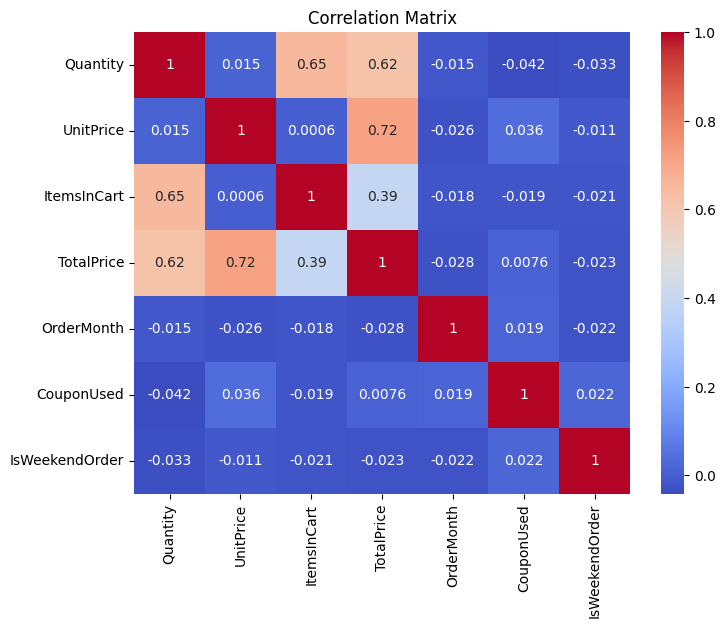

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
#ONE HOT ENCODING

In [41]:
print(df["Product"].nunique())
print(df["PaymentMethod"].nunique())
print(df["OrderStatus"].nunique())
print(df["ReferralSource"].nunique())
print(df["CouponCode"].nunique())

7
5
5
5
4


In [42]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Product",
        "PaymentMethod",
        "OrderStatus",
        "ReferralSource"
    ],
    drop_first=True,
    dtype=int
)

In [43]:
df_encoded.head()

,OrderID,Date,CustomerID,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,CouponCode,TotalPrice,...,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,ORD200000,2023-01-04,C72649,5,570.62,928 Main St,TRK37947903,7,SAVE10,2853.10,...,0,0,0,0,0,1,0,0,1,0
1,ORD200001,2024-08-23,C75739,2,151.35,823 Main St,TRK91186779,3,SAVE10,302.70,...,0,1,0,0,0,1,0,0,0,1
2,ORD200002,2024-02-27,C81728,5,550.68,512 Main St,TRK42903982,8,FREESHIP,2753.40,...,0,0,0,0,0,0,0,0,0,0
3,ORD200003,2023-10-15,C33540,1,273.19,275 Main St,TRK62788070,5,SAVE10,273.19,...,0,0,0,0,1,0,1,0,0,0
4,ORD200004,2025-05-08,C81840,4,626.01,668 Main St,TRK29241424,8,SAVE10,2504.04,...,0,1,1,0,0,0,0,0,0,0


In [44]:
print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (1200, 17)
Encoded Shape: (1200, 31)


In [45]:
df_encoded.to_csv("Cleaned_Ecommerce_Dataset.csv", index=False)

In [46]:
df.to_csv("Cleaned_Dataset.csv", index=False)
